# **Relatório de Classificação de Discurso de Ódio em Português**

O objetivo deste trabalho é avaliar a eficácia de um modelo de classificação de discurso de ódio utilizando a arquitetura BERT, comparando os desempenhos de dois conjuntos de dados: um com pré-processamento e outro sem. A análise se concentra em entender como as técnicas de limpeza de dados impactam a precisão da classificação e a detecção de discursos de ódio.

#### **Baixando/Importando as bibliotecas necessarias**

In [ ]:
!pip install transformers
!pip install pattern
!pip install nltk

In [ ]:
import re
import pandas as pd
import nltk
import string
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from pattern.vector import stemmer
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc

# Download de recursos do NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Configuração de stopwords
stop_words_pt = set(stopwords.words('portuguese'))
stop_words_en = set(stopwords.words('english'))
all_stop_words = stop_words_pt.union(stop_words_en)

# Inicialização do lemmatizer
lemmatizer = WordNetLemmatizer()

# Montagem do Google Drive (apenas para Colab)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Mounted at /content/drive


### **Funções de Pré-processamento**

#### **Carregando os dados**

In [ ]:
def load_portuguese_hate_speech():
    return pd.read_csv('/content/drive/MyDrive/disciplina-nlp/av2/data/portuguese_hate_speech.csv')

#### **Funções de Limpeza**

Nesta seção, elaboramos um dicionário que mapeia coloquialismos e gírias para suas formas padrão, bem como uma lista de abreviações que serão tratadas durante o pré-processamento do texto. A normalização dessas expressões é vital para que o modelo compreenda corretamente o conteúdo do texto.

In [ ]:
# Dicionário de coloquialismos, gírias e suas substituições
coloquialismos = {"vc": "você","vcs": "vocês","tb": "também","pq": "porque","blz": "beleza","blza": "beleza","ñ": "não","n": "não",
                  "q": "que","tá": "está","cê": "você","eh": "é","bora": "vamos","vamo": "vamos","blza": "beleza","soh": "só","kd": "cadê",
                  "aki": "aqui","eh": "é","dps": "depois","pf": "por favor","hj": "hoje","mt": "muito","mto": "muito","flw": "falou",
                  "vlw": "valeu","d": "de","tao": "estão","tão": "estão","mano": "cara","bro": "cara","krl": "caramba","blw": "beleza",
                  "tamo": "estamos","to": "estou","só": "somente","vdd": "verdade","fml": "família","ctz": "certeza","sqn": "só que não",
                  "vcê": "você","tbm": "também","tpw": "tipo","qnd": "quando","vlw": "valeu","fechô": "fechou","papo": "conversa"}

abbreviations = [
    'rt', 'vc', 'vcs','n', 'ta', 'p', 'd', 'eh', 'ne', 'pq', 'ha', 'pra', 'pnr', 'to', 'pro', 'tb', 'hj', 'ai',
    'ue', 'rs', 'q', 'ia', 'stf', 'pt', 'ngm', 'tt'
]

Definimos um conjunto de funções para realizar a limpeza e normalização dos dados textuais. O pré-processamento é uma etapa crítica no fluxo de trabalho de processamento de linguagem natural, pois garante que o modelo seja alimentado com dados de alta qualidade, livres de ruídos e inconsistências.

- As funções abaixo tratam diversos aspectos do texto, como a remoção de menções, links, números, pontuação e stopwords. Elas também realizam a normalização do texto, convertendo-o para minúsculas e substituindo coloquialismos.


- **A função preprocess_text integra todas essas etapas**, aplicando o pré-processamento de forma sequencial e organizada, resultando em um texto limpo e pronto para ser alimentado ao modelo.

In [ ]:
# Função para remover menções e links
def remove_mentions_and_links(text):
    text = re.sub(r'@\w+', '', text)  # Remove menções
    text = re.sub(r'http\S+', '', text)  # Remove links
    return text


# Função para converter o texto para minúsculas
def to_lowercase(text):
    return text.lower()


# Função para remover letras isoladas
def remove_single_letters(text):
    words = text.split()
    filtered_words = [word for word in words if len(word) > 1]
    return ' '.join(filtered_words)


def remove_abbreviations(text, abbreviation_list):
    tokens = text.split()
    valid_tokens = []

    for token in tokens:
        if token not in abbreviation_list:
            valid_tokens.append(token)

    return ' '.join(valid_tokens)


# Função para remover stopwords
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in all_stop_words]
    return ' '.join(filtered_words)


# Função para substituir ou remover coloquialismos
def replace_coloquialismos(text):
    words = text.split()
    replaced_words = [coloquialismos.get(word, word) for word in words]
    return ' '.join(replaced_words)


# Função para remover números
def remove_numbers(text):
    words = text.split()
    filtered_words = [word for word in words if not word.isdigit()]
    return ' '.join(filtered_words)


# Função para remover pontuação
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))


# Função para aplicar stemming
def apply_stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)


# Função para aplicar lematização
def apply_lemmatization(text):
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)


def remove_noise_symbols(raw_text):
    text = raw_text.replace('"', '')
    text = text.replace("'", '')
    text = text.replace("!", '')
    text = text.replace("`", '')
    text = text.replace("..", '')

    return text


# Função para aplicar todos os pré-processamentos
def preprocess_text(text):
    text = remove_mentions_and_links(text)
    text = remove_noise_symbols(text)
    text = remove_abbreviations(text, abbreviations)
    text = to_lowercase(text)
    text = remove_numbers(text)
    text = remove_single_letters(text)
    text = remove_stopwords(text)
    text = replace_coloquialismos(text)
    text = remove_punctuation(text)
    return text

### **Pré-processamento**

#### **Carregando o dataset**

Depois de definir as funções necessárias para o pré-processamento, esta seção carrega os dados e aplica as funções de limpeza e normalização ao texto. O objetivo é gerar uma nova coluna no DataFrame que contenha os textos tratados, que serão utilizados para o treinamento do modelo.

In [ ]:
df = load_portuguese_hate_speech()

In [ ]:
df['cleaned_text'] = df['text'].apply(preprocess_text)

#### **Balanceamento de Classes**

O balanceamento de classes é uma etapa fundamental para evitar viés no modelo, garantindo que ele tenha uma representação equitativa de todas as classes durante o treinamento. Isso é especialmente importante em tarefas de classificação, onde uma classe majoritária pode dominar a aprendizagem e prejudicar a capacidade do modelo de generalizar para a classe minoritária.

In [ ]:
class_counts = df['hatespeech_comb'].value_counts()
min_class_count = class_counts.min()

# Agora, realizamos a subamostragem da classe majoritária
balanced_df = pd.concat([
    df[df['hatespeech_comb'] == label].sample(min_class_count, random_state=42)
    for label in class_counts.index
])

# Embaralhar o DataFrame resultante
df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

####  **Classe de Detecção de Discurso de Ódio (HateSpeechClassifier)**

A criação de uma classe dedicada à classificação de discurso de ódio encapsula a lógica do modelo e o processo de inferência, tornando o código mais organizado, reutilizável e fácil de manter. Nesta classe, agrupamos os principais métodos necessários para carregar o modelo, processar dados de entrada e fazer previsões, mantendo a interface de uso simples e direta.




- **init:** O método construtor da classe recebe como parâmetros os caminhos do modelo e do tokenizador pré-treinados. Ele carrega o tokenizador e o modelo BERT para classificação de sequências, ajustando o modelo para o modo de avaliação (eval()), o que desativa certas funções como o cálculo de gradientes, otimizando o desempenho durante a inferência.

- **preprocess:** Este método realiza a tokenização do texto de entrada utilizando o tokenizador BERT, convertendo a sequência de texto em tensores adequados para serem processados pelo modelo. Ele aplica truncamento e preenchimento (padding) para garantir que todas as entradas tenham o mesmo comprimento.

- **predict:** Este método processa o texto usando o método de pré-processamento e realiza a inferência no modelo BERT. Ele desativa o cálculo de gradientes com torch.no_grad() para evitar o uso desnecessário de memória e processa a saída do modelo (logits), retornando a classe prevista (0 ou 1). A previsão retorna um valor binário: 0 para textos que não contêm discurso de ódio, e 1 para aqueles que o contêm.

In [ ]:
# Criar Dataset para o modelo
class HateSpeechDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

#### **Tokenização com BERT**

A tokenização é o processo de transformar o texto em uma sequência de tokens que possam ser interpretados pelo modelo BERT. Nesta etapa, utilizamos o tokenizador pré-treinado da biblioteca Hugging Face, que converte o texto em números inteiros que representam os tokens reconhecidos pelo modelo.

In [ ]:
# Tokenizador BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


#### Função create_dataset

create_dataset: Esta função é responsável por tokenizar os textos de entrada e criar um dataset formatado para treinamento e avaliação do modelo de classificação de discurso de ódio.

texts: Uma lista de textos de entrada que precisam ser tokenizados.
labels: Uma lista contendo as labels associadas a cada texto, indicando se contém ou não discurso de ódio.
tokenizer: Utiliza o tokenizador BERT para transformar o texto em tokens numéricos que podem ser compreendidos pelo modelo. A função aplica truncamento (truncation=True) para cortar textos que ultrapassem o limite de 128 tokens e padding (padding=True) para garantir que todas as sequências tenham o mesmo comprimento.
return: Retorna um objeto do tipo HateSpeechDataset, que contém os textos tokenizados e suas labels associadas. Este dataset pode ser diretamente usado no treinamento ou avaliação de modelos.

In [ ]:
# Função para tokenizar e criar dataset
def create_dataset(texts, labels):
    encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=128)
    return HateSpeechDataset(encodings, list(labels))

### **Separação de dados de treino e de teste**

In [ ]:
# Dividir e criar dataset para dados pré-processados
train_texts_clean, test_texts_clean, train_labels_clean, test_labels_clean = train_test_split(
    df['cleaned_text'], df['hatespeech_comb'], test_size=0.3, random_state=42
)
train_dataset_clean = create_dataset(train_texts_clean, train_labels_clean)
test_dataset_clean = create_dataset(test_texts_clean, test_labels_clean)

In [ ]:
# Dividir e criar dataset para dados sem pré-processamento
train_texts_raw, test_texts_raw, train_labels_raw, test_labels_raw = train_test_split(
    df['text'], df['hatespeech_comb'], test_size=0.3, random_state=42
)
train_dataset_raw = create_dataset(train_texts_raw, train_labels_raw)
test_dataset_raw = create_dataset(test_texts_raw, test_labels_raw)

### **Modelagem**

Nesta etapa, utilizamos o modelo BERT pré-treinado para sequências de classificação, ajustando-o especificamente para a tarefa de detecção de discurso de ódio. O BERT (Bidirectional Encoder Representations from Transformers) é um dos modelos de linguagem mais avançados e eficazes em tarefas de processamento de linguagem natural (PLN), particularmente útil em classificação de texto. Ao carregar um modelo pré-treinado, podemos aproveitar o conhecimento adquirido durante o treinamento em grandes corpora e ajustá-lo para a detecção de discurso de ódio em nosso conjunto de dados específico.

In [ ]:
# Carregar o modelo BERT
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#### **Configuração do Processo de Treinamento**

A configuração do processo de treinamento é essencial para otimizar o desempenho do modelo. Nesta seção, especificamos os parâmetros de treinamento, como o número de épocas, o tamanho do batch, a estratégia de avaliação, e o diretório de saída para os resultados.


In [ ]:
# Configurar o treinamento
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    weight_decay=0.00001,
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


A função compute_metrics é responsável por calcular as principais métricas que serão usadas para avaliar o desempenho do modelo, como acurácia, precisão, recall, F1-score, e a Área Sob a Curva ROC (ROC-AUC).

In [ ]:
# Função para calcular métricas
def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average='binary', zero_division=0)
    acc = accuracy_score(p.label_ids, preds)

    # Matriz de Confusão
    cm = confusion_matrix(p.label_ids, preds)

    # Curva ROC
    fpr, tpr, _ = roc_curve(p.label_ids, p.predictions[:, 1])
    roc_auc = auc(fpr, tpr)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc_auc,
        "confusion_matrix": cm.tolist(),  # Converter para lista
    }

### **Treinamento dados pré-processados**

In [ ]:
# Treinamento para dados pré-processados
trainer_clean = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_clean,
    eval_dataset=test_dataset_clean,
    compute_metrics=compute_metrics,
)

trainer_clean.train()
eval_result_clean = trainer_clean.evaluate()
print(f"Resultados do modelo LLM BERT (pré-processados): {eval_result_clean}")

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc,Confusion Matrix
1,No log,0.679024,0.547996,0.645208,0.512195,0.871542,0.681926,"[[147, 420], [65, 441]]"
2,No log,0.650106,0.674744,0.563204,0.767918,0.444664,0.742459,"[[499, 68], [281, 225]]"
3,No log,0.713085,0.679404,0.643154,0.676856,0.612648,0.732822,"[[419, 148], [196, 310]]"
4,No log,0.845662,0.688723,0.672549,0.667315,0.677866,0.733449,"[[396, 171], [163, 343]]"
5,No log,0.983451,0.688723,0.644681,0.698157,0.598814,0.733599,"[[436, 131], [203, 303]]"
6,No log,1.202564,0.681267,0.651020,0.672996,0.630435,0.726394,"[[412, 155], [187, 319]]"
7,0.388100,1.400725,0.669152,0.652981,0.646035,0.660079,0.719211,"[[384, 183], [172, 334]]"
8,0.388100,1.510446,0.672880,0.681777,0.629816,0.743083,0.717440,"[[346, 221], [130, 376]]"
9,0.388100,1.639571,0.678472,0.639498,0.678492,0.604743,0.725642,"[[422, 145], [200, 306]]"
10,0.388100,1.687898,0.678472,0.646154,0.671642,0.622530,0.726642,"[[413, 154], [191, 315]]"


Trainer is attempting to log a value of "[[147, 420], [65, 441]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[[499, 68], [281, 225]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[[419, 148], [196, 310]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[[396, 171], [163, 343]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[[436, 131], [203, 303]]" of type <cl

Trainer is attempting to log a value of "[[413, 154], [191, 315]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.


Resultados do modelo LLM BERT (pré-processados): {'eval_loss': 1.6878981590270996, 'eval_accuracy': 0.6784715750232991, 'eval_f1': 0.6461538461538461, 'eval_precision': 0.6716417910447762, 'eval_recall': 0.6225296442687747, 'eval_roc_auc': 0.7266418498302557, 'eval_confusion_matrix': [[413, 154], [191, 315]], 'eval_runtime': 2.8163, 'eval_samples_per_second': 381.003, 'eval_steps_per_second': 12.073, 'epoch': 10.0}


### **Treinamento sem pré-processamento**

In [ ]:
# Treinamento para dados sem pré-processamento
trainer_raw = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_raw,
    eval_dataset=test_dataset_raw,
    compute_metrics=compute_metrics,
)

trainer_raw.train()
eval_result_raw = trainer_raw.evaluate()
print(f"Resultados do modelo LLM BERT (sem pré-processamento): {eval_result_raw}")

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc,Confusion Matrix
1,No log,0.868266,0.666356,0.694017,0.611446,0.802372,0.727137,"[[309, 258], [100, 406]]"
2,No log,1.050285,0.674744,0.614365,0.696742,0.549407,0.731727,"[[446, 121], [228, 278]]"
3,No log,1.543730,0.649581,0.569794,0.676630,0.492095,0.715314,"[[448, 119], [257, 249]]"
4,No log,1.512655,0.679404,0.654618,0.665306,0.644269,0.725962,"[[403, 164], [180, 326]]"
5,No log,1.377707,0.679404,0.626898,0.694712,0.571146,0.724122,"[[440, 127], [217, 289]]"
6,No log,1.931738,0.670084,0.645291,0.654472,0.636364,0.718043,"[[397, 170], [184, 322]]"
7,0.160900,2.005692,0.683131,0.639831,0.689498,0.596838,0.711546,"[[431, 136], [204, 302]]"
8,0.160900,2.005604,0.681267,0.650307,0.673729,0.628458,0.713770,"[[413, 154], [188, 318]]"
9,0.160900,2.095721,0.681267,0.648148,0.675966,0.622530,0.716694,"[[416, 151], [191, 315]]"
10,0.160900,2.114073,0.683131,0.648760,0.679654,0.620553,0.718744,"[[419, 148], [192, 314]]"


Trainer is attempting to log a value of "[[309, 258], [100, 406]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[[446, 121], [228, 278]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[[448, 119], [257, 249]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[[403, 164], [180, 326]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[[440, 127], [217, 289]]" of type <

Trainer is attempting to log a value of "[[419, 148], [192, 314]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.


Resultados do modelo LLM BERT (sem pré-processamento): {'eval_loss': 2.114072561264038, 'eval_accuracy': 0.6831314072693383, 'eval_f1': 0.6487603305785123, 'eval_precision': 0.6796536796536796, 'eval_recall': 0.6205533596837944, 'eval_roc_auc': 0.7187436825117985, 'eval_confusion_matrix': [[419, 148], [192, 314]], 'eval_runtime': 4.1696, 'eval_samples_per_second': 257.34, 'eval_steps_per_second': 8.154, 'epoch': 10.0}


### **Resultados: Classificação de Discurso de Ódio com BERT**

Neste experimento, dois modelos de classificação de discurso de ódio foram treinados utilizando a arquitetura BERT. Um modelo foi treinado com dados pré-processados e outro com dados sem pré-processamento, a fim de avaliar o impacto das técnicas de limpeza de dados no desempenho geral do classificador. Os resultados foram avaliados por meio de matrizes de confusão, curvas ROC e a métrica AUC (Área sob a Curva).


<br>

**1. Matrizes de Confusão** <br>


<table border="1">
  <tr>
    <th>Métrica</th>
    <th>Modelo sem Pré-processamento</th>
    <th>Modelo com Pré-processamento</th>
  </tr>
  <tr>
    <td>Verdadeiros Positivos</td>
    <td>314</td>
    <td>315</td>
  </tr>
  <tr>
    <td>Verdadeiros Negativos</td>
    <td>419</td>
    <td>413</td>
  </tr>
  <tr>
    <td>Falsos Positivos</td>
    <td>148</td>
    <td>154</td>
  </tr>
  <tr>
    <td>Falsos Negativos</td>
    <td>192</td>
    <td>191</td>
  </tr>
</table>


Análise: O modelo sem pré-processamento apresentou um número ligeiramente maior de verdadeiros negativos, indicando uma maior precisão na detecção de instâncias que não são discurso de ódio. Entretanto, o modelo com pré-processamento teve um desempenho ligeiramente superior no número de verdadeiros positivos.


<br>

**2. Curvas ROC e AUC** <br>


<table border="1">
  <tr>
    <th>Modelo</th>
    <th>AUC</th>
  </tr>
  <tr>
    <td>Modelo sem Pré-processamento</td>
    <td>0.72</td>
  </tr>
  <tr>
    <td>Modelo com Pré-processamento</td>
    <td>0.73</td>
  </tr>
</table>

Análise: A diferença nas áreas sob a curva (AUC) foi pequena, com o modelo pré-processado apresentando uma leve vantagem. Isso sugere que o pré-processamento dos dados contribuiu para uma classificação um pouco mais precisa, mas o ganho foi marginal.

In [ ]:
# @title
# Função para plotar a matriz de confusão
def plot_confusion_matrix(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_ylabel('Real')
    ax.set_xlabel('Previsto')
    ax.set_title(title)

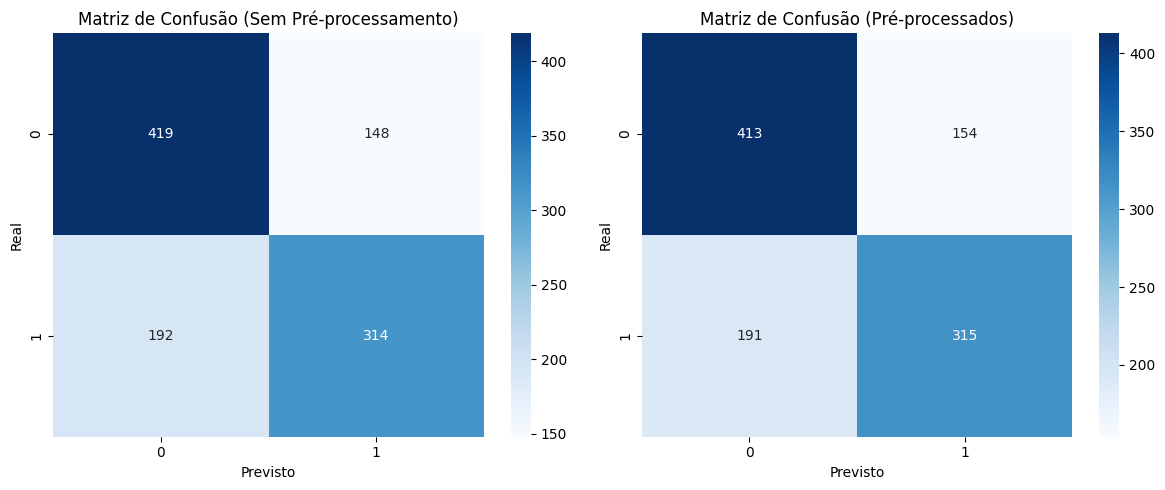

In [ ]:
# @title
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusão para dados sem pré-processamento
cm_raw = eval_result_raw.get('eval_confusion_matrix', [])
plot_confusion_matrix(cm_raw, 'Matriz de Confusão (Sem Pré-processamento)', axs[0])

# Matriz de confusão para dados pré-processados
cm_clean = eval_result_clean.get('eval_confusion_matrix', [])
plot_confusion_matrix(cm_clean, 'Matriz de Confusão (Pré-processados)', axs[1])

plt.tight_layout()
plt.show()

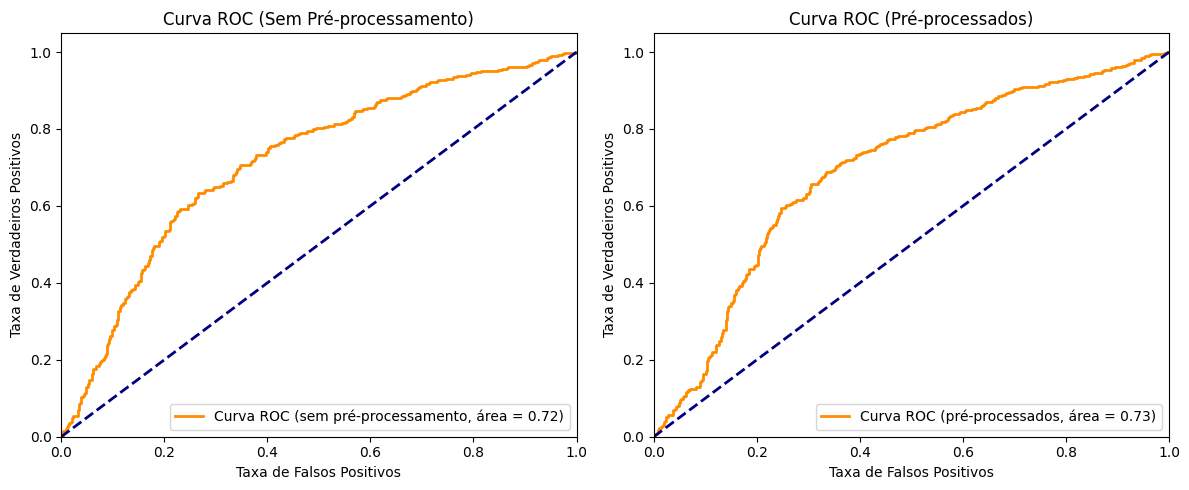

In [ ]:
# @title
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plotar a Curva ROC para dados sem pré-processamento
fpr_raw, tpr_raw, _ = roc_curve(test_labels_raw, trainer_raw.predict(test_dataset_raw).predictions[:, 1])
axs[0].plot(fpr_raw, tpr_raw, color='darkorange', lw=2,
            label='Curva ROC (sem pré-processamento, área = %0.2f)' % eval_result_raw.get('eval_roc_auc', []))
axs[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axs[0].set_xlim([0.0, 1.0])
axs[0].set_ylim([0.0, 1.05])
axs[0].set_xlabel('Taxa de Falsos Positivos')
axs[0].set_ylabel('Taxa de Verdadeiros Positivos')
axs[0].set_title('Curva ROC (Sem Pré-processamento)')
axs[0].legend(loc="lower right")

# Plotar a Curva ROC para dados pré-processados
fpr_clean, tpr_clean, _ = roc_curve(test_labels_clean, trainer_clean.predict(test_dataset_clean).predictions[:, 1])
axs[1].plot(fpr_clean, tpr_clean, color='darkorange', lw=2,
            label='Curva ROC (pré-processados, área = %0.2f)' % eval_result_clean.get('eval_roc_auc', []))
axs[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axs[1].set_xlim([0.0, 1.0])
axs[1].set_ylim([0.0, 1.05])
axs[1].set_xlabel('Taxa de Falsos Positivos')
axs[1].set_ylabel('Taxa de Verdadeiros Positivos')
axs[1].set_title('Curva ROC (Pré-processados)')
axs[1].legend(loc="lower right")


plt.tight_layout()
plt.show()

Os dois modelos apresentaram desempenhos semelhantes, com pequenas variações. O pré-processamento trouxe uma ligeira melhoria na precisão do modelo (AUC de 0.73 vs. 0.72), mas também resultou em um número levemente maior de falsos positivos. Por outro lado, o modelo sem pré-processamento se mostrou mais eficaz em identificar instâncias que não são discurso de ódio.

**Próximos Passos**

Com base nesses resultados, os próximos passos incluem:

- Aprimorar o pré-processamento dos dados, buscando reduzir o número de falsos positivos.
- Testar novas arquiteturas de modelo ou ajustar os hiperparâmetros para melhorar a capacidade de detecção de discursos de ódio sem sacrificar a precisão.